In [1]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Timer
from sklearn.model_selection import KFold
from lion_pytorch import Lion
import warnings
from pathlib import Path
from fukui_net.utils.utils import MoleculeDataModule, evaluate_model
from fukui_net.utils.train import MoleculeModel
from torch_geometric.nn import ChebConv
from torch_scatter import scatter_mean
import torch.nn.functional as F
from fukui_net.utils.efficient_kan import KAN, KANLinear



import numpy as np
import random


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

def initialize_cuda(device_id=0):
    if torch.cuda.is_available():
        torch.cuda.set_device(device_id)
        torch.cuda.manual_seed_all(42)
        print("CUDA is available")
        print(torch.cuda.get_device_name(device_id))
        torch.cuda.empty_cache()
    else:
        print("CUDA is not available.")

initialize_cuda() 

warnings.filterwarnings("ignore", category=UserWarning, module="pytorch_lightning.trainer.connectors.data_connector")
warnings.filterwarnings("ignore", category=UserWarning, module="lightning_fabric.plugins.environments.slurm")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.set_float32_matmul_precision('medium')

In [24]:
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from torch_geometric.data import DataLoader as GeoDataLoader
from tqdm import tqdm

def evaluate_model_full(model, dataset, batch_size):
    dataloader = GeoDataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=32)
    model.eval()
    all_pred, all_true = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            batch = batch.to(model.device)
            y_hat = model(batch.x, batch.edge_index, batch.edge_attr)
            all_pred.extend(y_hat.cpu().numpy())
            all_true.extend(batch.y.cpu().numpy())

    all_pred, all_true = np.array(all_pred), np.array(all_true)
    rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    r2 = r2_score(all_true, all_pred)

    print(f'Total RMSE: {rmse:.4f}')
    print(f'Total R²: {r2:.4f}')

In [25]:
class AtomEdgeInteraction(nn.Module):
    def __init__(self, in_features, edge_features, out_features, edge_importance=1.0, dropout_rate=0.1, use_batch_norm=True):
        super(AtomEdgeInteraction, self).__init__()
        self.edge_importance = edge_importance
        self.interaction = KANLinear(in_features + edge_features, out_features)
        self.activation = nn.ReLU()
        self.batch_norm = nn.BatchNorm1d(out_features) if use_batch_norm else nn.Identity()
        self.dropout = nn.Dropout(dropout_rate)
        self.residual = nn.Linear(in_features, out_features) if in_features != out_features else nn.Identity()

    def forward(self, x, edge_index, edge_attr):
        row, col = edge_index
        edge_features = edge_attr * self.edge_importance
        atom_features = x[row]
        combined_features = torch.cat([atom_features, edge_features], dim=-1)
        updated_features = self.interaction(combined_features)
        updated_features = self.activation(updated_features)
        updated_features = self.batch_norm(updated_features)
        updated_features = self.dropout(updated_features)
        residual_features = self.residual(x)
        x = scatter_mean(updated_features, col, dim=0, dim_size=x.size(0))
        return x + residual_features

class Model(nn.Module):
    def __init__(self, atom_in_features, edge_attr_dim, preprocess_hidden_features, cheb_hidden_features, K, cheb_normalizations, dropout_rates, activation_fns, use_batch_norm, postprocess_hidden_features, out_features):
        super(Model, self).__init__()

        self.atom_preprocess = nn.ModuleList([AtomEdgeInteraction(atom_in_features, edge_attr_dim, preprocess_hidden_features[0], dropout_rate=dropout_rates[0], use_batch_norm=use_batch_norm[0])])
        for i in range(1, len(preprocess_hidden_features)):
            layer = nn.Sequential(
                KANLinear(preprocess_hidden_features[i-1], preprocess_hidden_features[i]),
                nn.BatchNorm1d(preprocess_hidden_features[i]) if use_batch_norm[i] else nn.Identity(),
                activation_fns[i](),
                nn.Dropout(dropout_rates[i])
            )
            self.atom_preprocess.append(layer)

        self.cheb_convolutions = nn.ModuleList()
        in_channels = preprocess_hidden_features[-1]
        for i in range(len(cheb_hidden_features)):
            self.cheb_convolutions.append(ChebConv(in_channels, cheb_hidden_features[i], K[i], normalization=cheb_normalizations[i]))
            in_channels = cheb_hidden_features[i]

        self.postprocess = nn.ModuleList()
        for i in range(len(postprocess_hidden_features)):
            layer = nn.Sequential(
                KANLinear(cheb_hidden_features[i-1] if i > 0 else cheb_hidden_features[-1], postprocess_hidden_features[i]),
                nn.BatchNorm1d(postprocess_hidden_features[i]) if use_batch_norm[len(preprocess_hidden_features) + i] else nn.Identity(),
                activation_fns[len(preprocess_hidden_features) + i](),
                nn.Dropout(dropout_rates[len(preprocess_hidden_features) + i])
            )
            self.postprocess.append(layer)

        self.output_layer = KANLinear(postprocess_hidden_features[-1], out_features)

    def forward(self, x, edge_index, edge_attr):
        x = self.atom_preprocess[0](x, edge_index, edge_attr)
        for layer in self.atom_preprocess[1:]:
            x = layer(x)

        for conv in self.cheb_convolutions:
            x = F.relu(conv(x, edge_index))

        for layer in self.postprocess:
            x = layer(x)

        return self.output_layer(x).squeeze(-1)


In [ ]:
# %%
import torch
import torch.nn as nn
import pytorch_lightning as pl
from lion_pytorch import Lion
from fukui_net.utils.utils import MoleculeDataModule, evaluate_model
from fukui_net.utils.train import MoleculeModel
from torch_geometric.nn import ChebConv
from torch_scatter import scatter_mean
import torch.nn.functional as F

in_features = 133
out_features = 1
edge_attr_dim = 14

batch_size = 1024
num_workers = 8

preprocess_hidden_features = [128] * 9
postprocess_hidden_features = [128, 128]
cheb_hidden_features = [128, 128]
K = [10, 16]
cheb_normalization = ['sym', 'sym']

dropout_rates = [0.0] * (len(preprocess_hidden_features) + len(postprocess_hidden_features))
activation_fns = [nn.PReLU] * (len(preprocess_hidden_features) + len(postprocess_hidden_features))
use_batch_norm = [True] * (len(preprocess_hidden_features) + len(postprocess_hidden_features))

learning_rate = 2.2e-5
weight_decay = 3e-5
step_size = 30
gamma = 0.2
metric = 'rmse'

# Определение архитектуры модели
backbone = Model(
    atom_in_features=in_features,
    edge_attr_dim=edge_attr_dim,
    preprocess_hidden_features=preprocess_hidden_features,
    cheb_hidden_features=cheb_hidden_features,
    K=K,
    cheb_normalizations=cheb_normalization,
    dropout_rates=dropout_rates,
    activation_fns=activation_fns,
    use_batch_norm=use_batch_norm,
    postprocess_hidden_features=postprocess_hidden_features,
    out_features=out_features
)

# Инициализация модели
model = MoleculeModel(
    model_backbone=backbone,
    optimizer_class=Lion,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    step_size=step_size,
    gamma=gamma,
    batch_size=batch_size,
    metric=metric
)

# Загрузка контрольной точки
checkpoint_path = '/home/nikolenko/work/Projects/fukui_index_prediction/models/final_model.ckpt'
model = MoleculeModel.load_from_checkpoint(checkpoint_path, model_backbone=backbone)

print("Model loaded for finetuning.")



In [1]:
import torch 

batch_size = 1024 
num_workers = 8  
dataset = torch.load(f'../data/processed/QM_137k.pt')
#data_module = MoleculeDataModule(dataset, batch_size=batch_size, num_workers=num_workers)

In [2]:
dataset[0]

Data(x=[31, 133], edge_index=[2, 64], edge_attr=[64, 14], y=[31], smiles='CNC(=S)N/N=C/c1c(O)ccc2ccccc12')

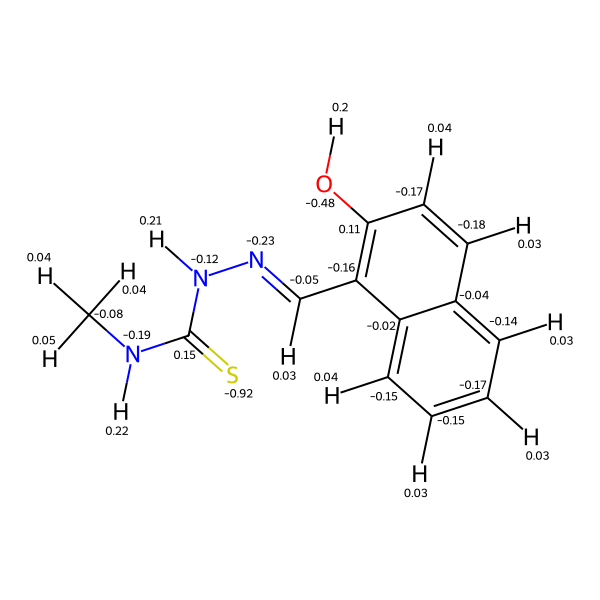

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw
import numpy as np
from IPython.display import display

def draw_molecule(smiles, predictions):
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    predictions_rounded = np.round(predictions, 2)
    for atom, pred in zip(mol.GetAtoms(), predictions_rounded):
        atom.SetProp('atomNote', str(pred))
    img = Draw.MolToImage(mol, size=(600, 600), kekulize=True)
    display(img)

smiles = dataset[0].smiles
predictions = dataset[0].y.numpy()

draw_molecule(smiles, predictions)

In [4]:
list(predictions) 

[-0.07558,
 -0.188025,
 0.152735,
 -0.91942,
 -0.120406,
 -0.233292,
 -0.046101,
 -0.161956,
 0.105481,
 -0.482595,
 -0.169458,
 -0.181011,
 -0.044773,
 -0.140508,
 -0.168578,
 -0.150217,
 -0.148796,
 -0.018987,
 0.047372,
 0.04355,
 0.039966,
 0.217311,
 0.213282,
 0.034117,
 0.198394,
 0.041348,
 0.02535,
 0.034482,
 0.02831,
 0.031216,
 0.036851]

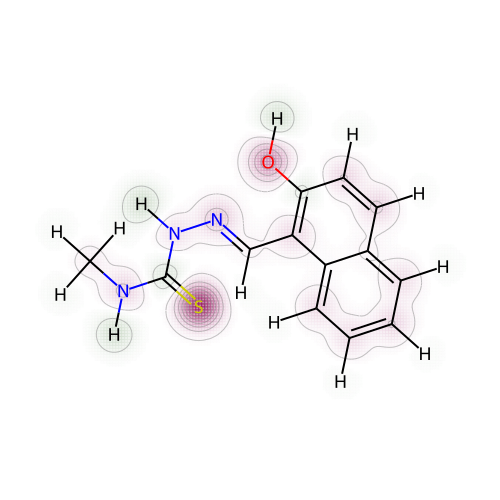

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps
import io
from PIL import Image
from IPython.display import display

def show_png(data):
    bio = io.BytesIO(data)
    img = Image.open(bio)
    return img

smiles = dataset[0].smiles
predictions = dataset[0].y.numpy()
predictions = [float(x) for x in predictions]

mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)

d = Draw.MolDraw2DCairo(500, 500)
SimilarityMaps.GetSimilarityMapFromWeights(mol, predictions, draw2d=d)
d.FinishDrawing()
img = show_png(d.GetDrawingText())
display(img)


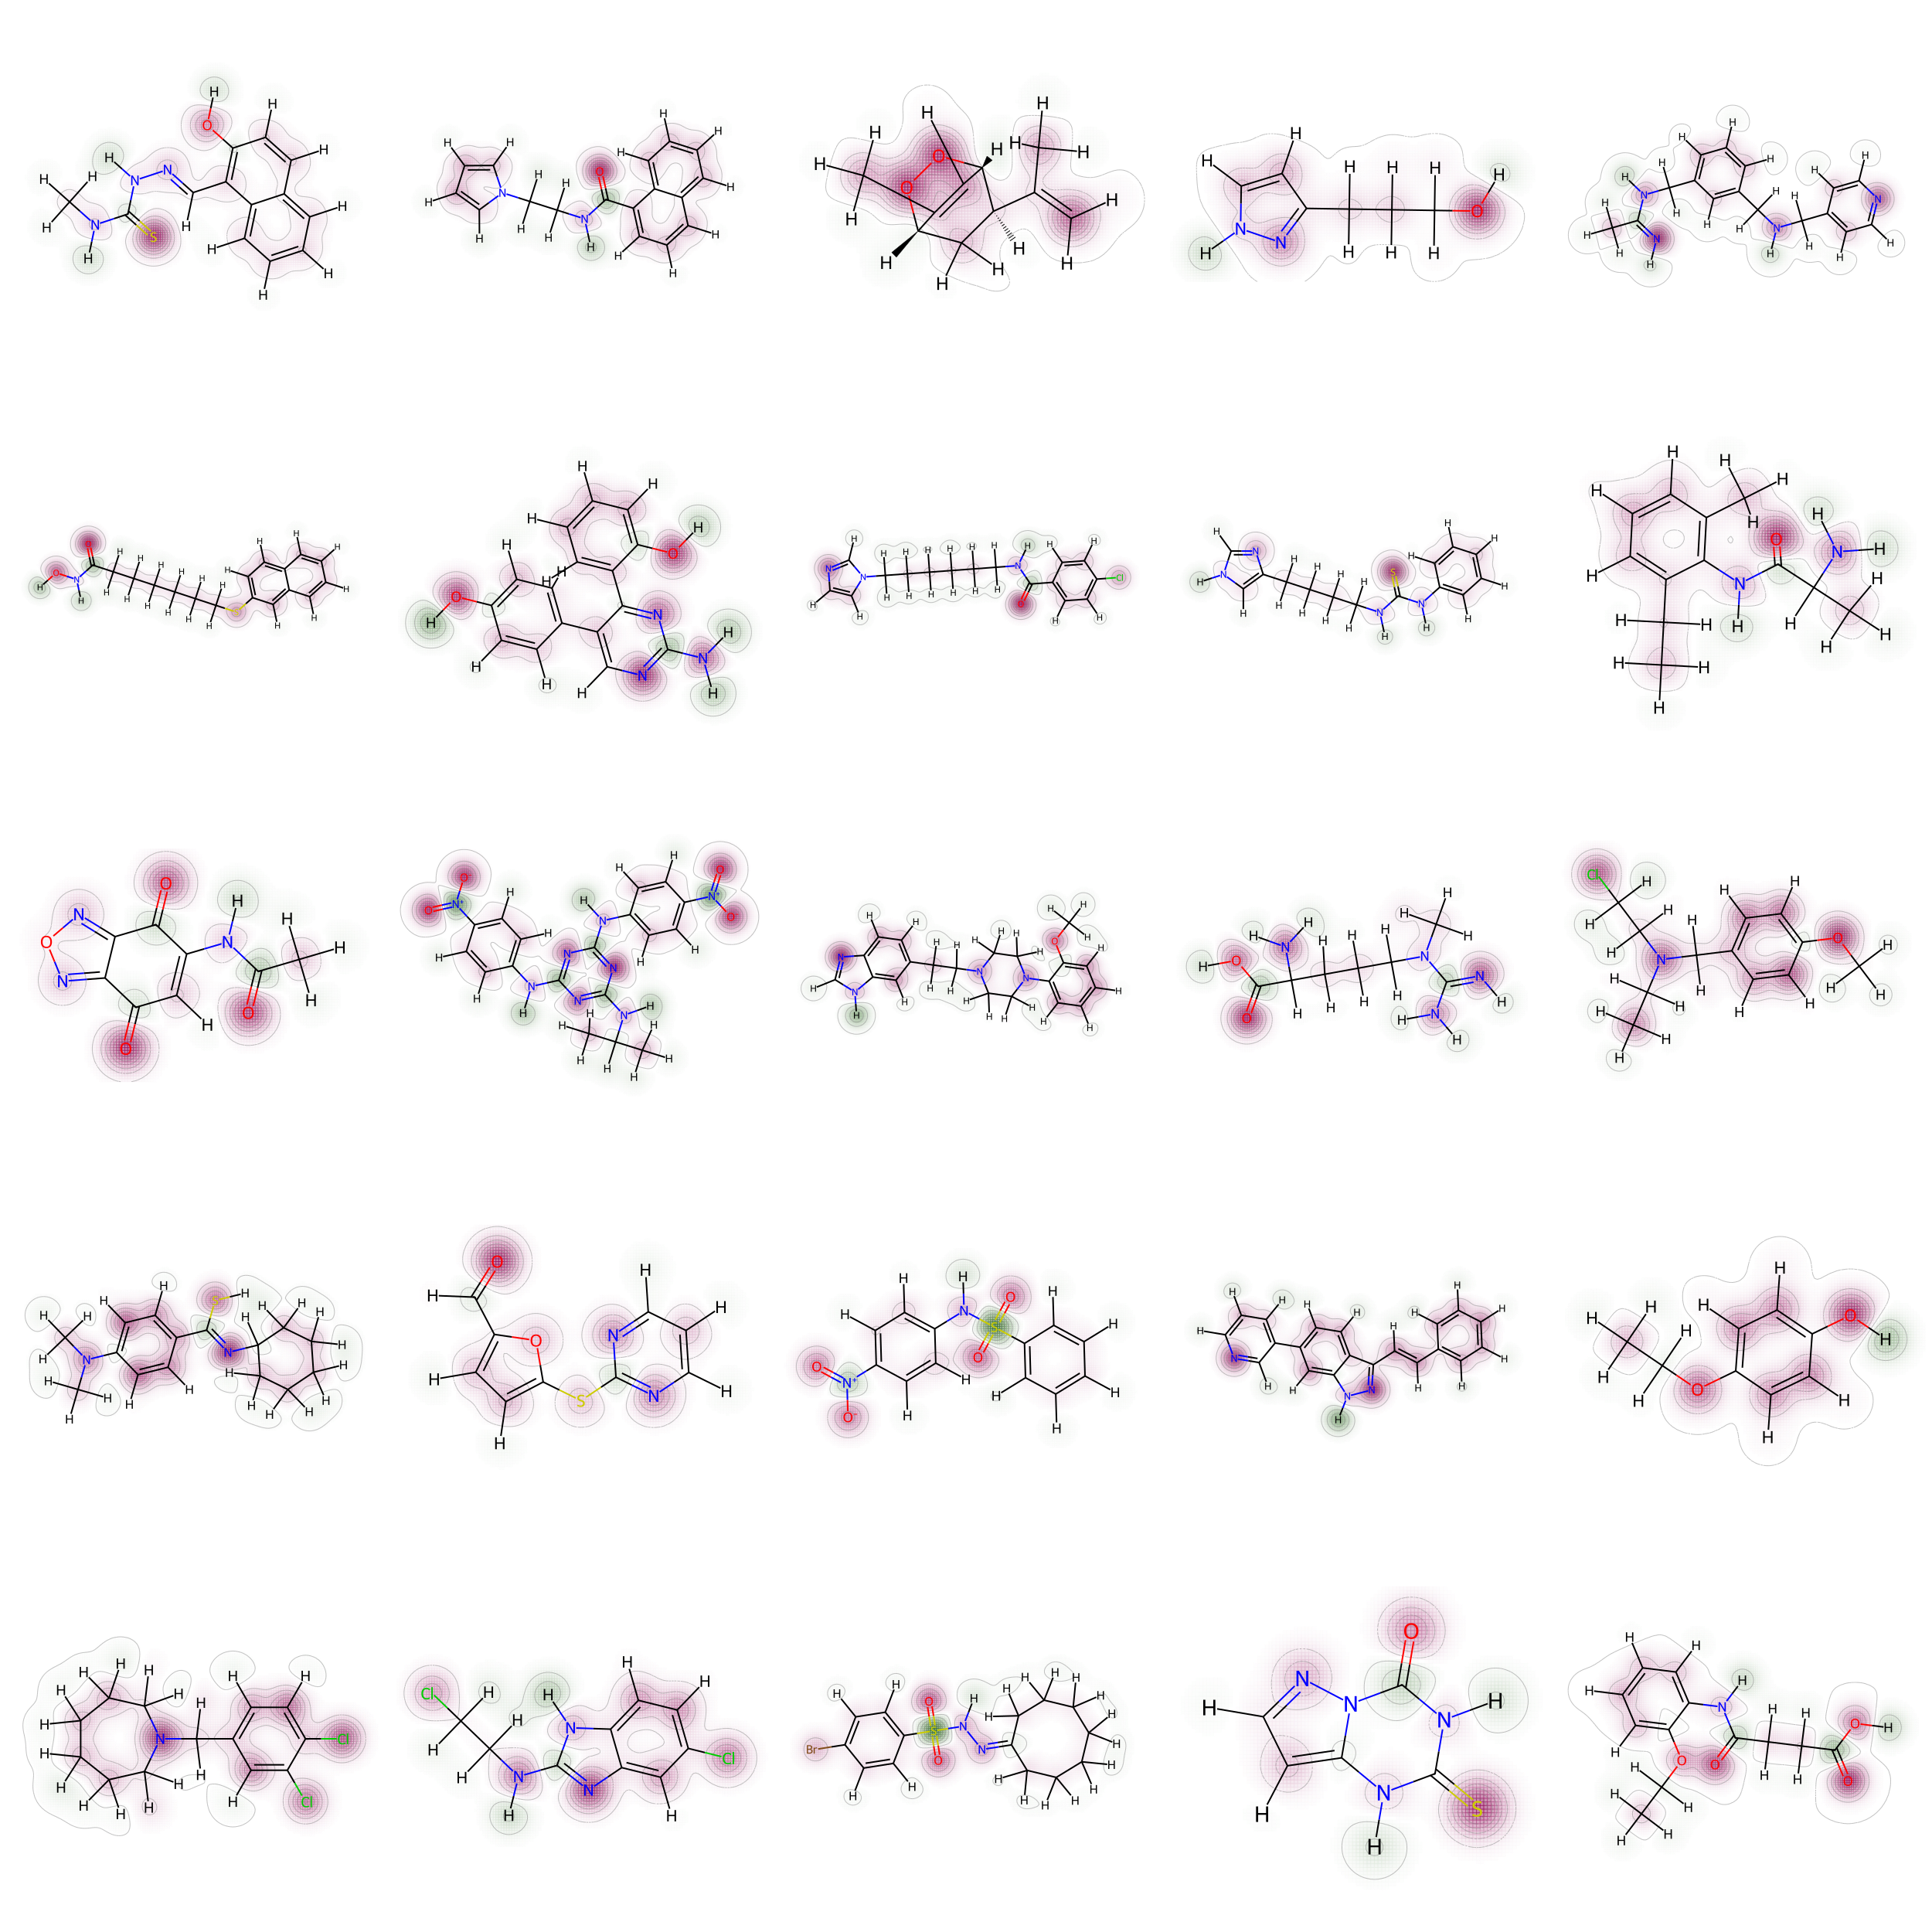

In [13]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps
import io
from PIL import Image
from IPython.display import display
import numpy as np

def show_png(data):
    bio = io.BytesIO(data)
    return Image.open(bio)

grid_size = 5
images = []
for i in range(grid_size * grid_size):
    smiles = dataset[i].smiles
    predictions = [float(x) for x in dataset[i].y.numpy()]
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    d = Draw.MolDraw2DCairo(500, 500)
    SimilarityMaps.GetSimilarityMapFromWeights(mol, predictions, sigma=0.5, draw2d=d)
    d.FinishDrawing()
    img = show_png(d.GetDrawingText())
    images.append(img)

grid_img = Image.new('RGB', (500 * grid_size, 500 * grid_size))
for r in range(grid_size):
    for c in range(grid_size):
        index = r * grid_size + c
        grid_img.paste(images[index], (c * 500, r * 500))

display(grid_img)
